# Merge figures

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({"font.family":"serif","font.serif":["DejaVu Serif"],"font.weight":"normal","axes.titleweight":"normal","figure.titleweight":"normal","mathtext.fontset":"dejavuserif"})

def _offset(cell,obj,mode):
    if mode=="left" or mode=="top": return 0
    if mode=="right" or mode=="bottom": return cell-obj
    return (cell-obj)//2

def _merge_rasters(image_paths,ncol,nrow,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"):
    annotate_color="#000"; paths=[]; labels=[]
    for item in image_paths:
        if isinstance(item,(list,tuple)): paths.append(item[0]); labels.append(item[1] if len(item)>1 else None)
        else: paths.append(item); labels.append(None)
    if len(paths)!=ncol*nrow: raise ValueError(f"This function requires exactly {ncol*nrow} images.")
    images=[Image.open(path).convert("RGB") for path in paths]
    placements=[(row+col*nrow,col,row) for row in range(nrow) for col in range(ncol)]
    col_widths=[max(images[i].size[0] for i,c,r in placements if c==col) for col in range(ncol)]
    row_heights=[max(images[i].size[1] for i,c,r in placements if r==row) for row in range(nrow)]
    result_width,result_height=sum(col_widths),sum(row_heights)
    if label_fontsize is None: label_fontsize=max(14,int(min(max(col_widths),max(row_heights))*0.03))
    result=Image.new("RGB",(result_width,result_height),(255,255,255))
    for i,col,row in placements:
        img=images[i]; w_img,h_img=img.size; x0=sum(col_widths[:col]); y0=sum(row_heights[:row])
        x=x0+_offset(col_widths[col],w_img,halign); y=y0+_offset(row_heights[row],h_img,valign)
        result.paste(img,(x,y))
    fig,ax=plt.subplots(figsize=(result_width/dpi,result_height/dpi),dpi=dpi)
    ax.imshow(result,interpolation="none"); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    if divider:
        for y in [sum(row_heights[:k])-0.5 for k in range(1,nrow)]: ax.axhline(y=y,color=line_color,linewidth=divider_linewidth,zorder=3)
        for x in [sum(col_widths[:k])-0.5 for k in range(1,ncol)]: ax.axvline(x=x,color=line_color,linewidth=divider_linewidth,zorder=3)
    if border: ax.add_patch(Rectangle((-0.5,-0.5),result_width,result_height,fill=False,edgecolor=line_color,linewidth=border_linewidth,clip_on=False,zorder=4))
    bbox_style=dict(boxstyle="round,pad=0.4",facecolor="white",edgecolor="#808080",linewidth=2,alpha=0.8)
    for i,col,row in placements:
        label=labels[i]
        if label is None or str(label).strip()=="": continue
        img=images[i]; w_img,h_img=img.size; x0=sum(col_widths[:col]); y0=sum(row_heights[:row])
        cell_w,cell_h=col_widths[col],row_heights[row]
        pad_x,pad_y=label_pad if label_pad is not None else ((cell_w+cell_h)/50,(cell_w+cell_h)/50)
        x=x0+_offset(cell_w,w_img,halign)+pad_x; y=y0+_offset(cell_h,h_img,valign)+pad_y
        ax.text(x,y,str(label),color=annotate_color,fontsize=label_fontsize,ha="left",va="top",fontweight="normal",bbox=bbox_style,wrap=True,zorder=5)
    if suptitle: fig.suptitle(suptitle,fontsize=20,y=0.98,fontweight="normal"); fig.subplots_adjust(left=0,right=1,bottom=0,top=0.94)
    else: fig.subplots_adjust(left=0,right=1,bottom=0,top=1)
    # plt.show()

def merge_2_rasters_hor(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,2,1,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_2_rasters_ver(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,1,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_3_rasters_hor(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,1,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_3_rasters_ver(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,1,3,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_4_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,2,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_6_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,2,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)
def merge_9_rasters(image_paths,suptitle=None,label_fontsize=None,label_pad=None,dpi=150,border=True,divider=True,border_linewidth=6,divider_linewidth=6,line_color="#323232",halign="center",valign="center"): _merge_rasters(image_paths,3,3,suptitle,label_fontsize,label_pad,dpi,border,divider,border_linewidth,divider_linewidth,line_color,halign,valign)


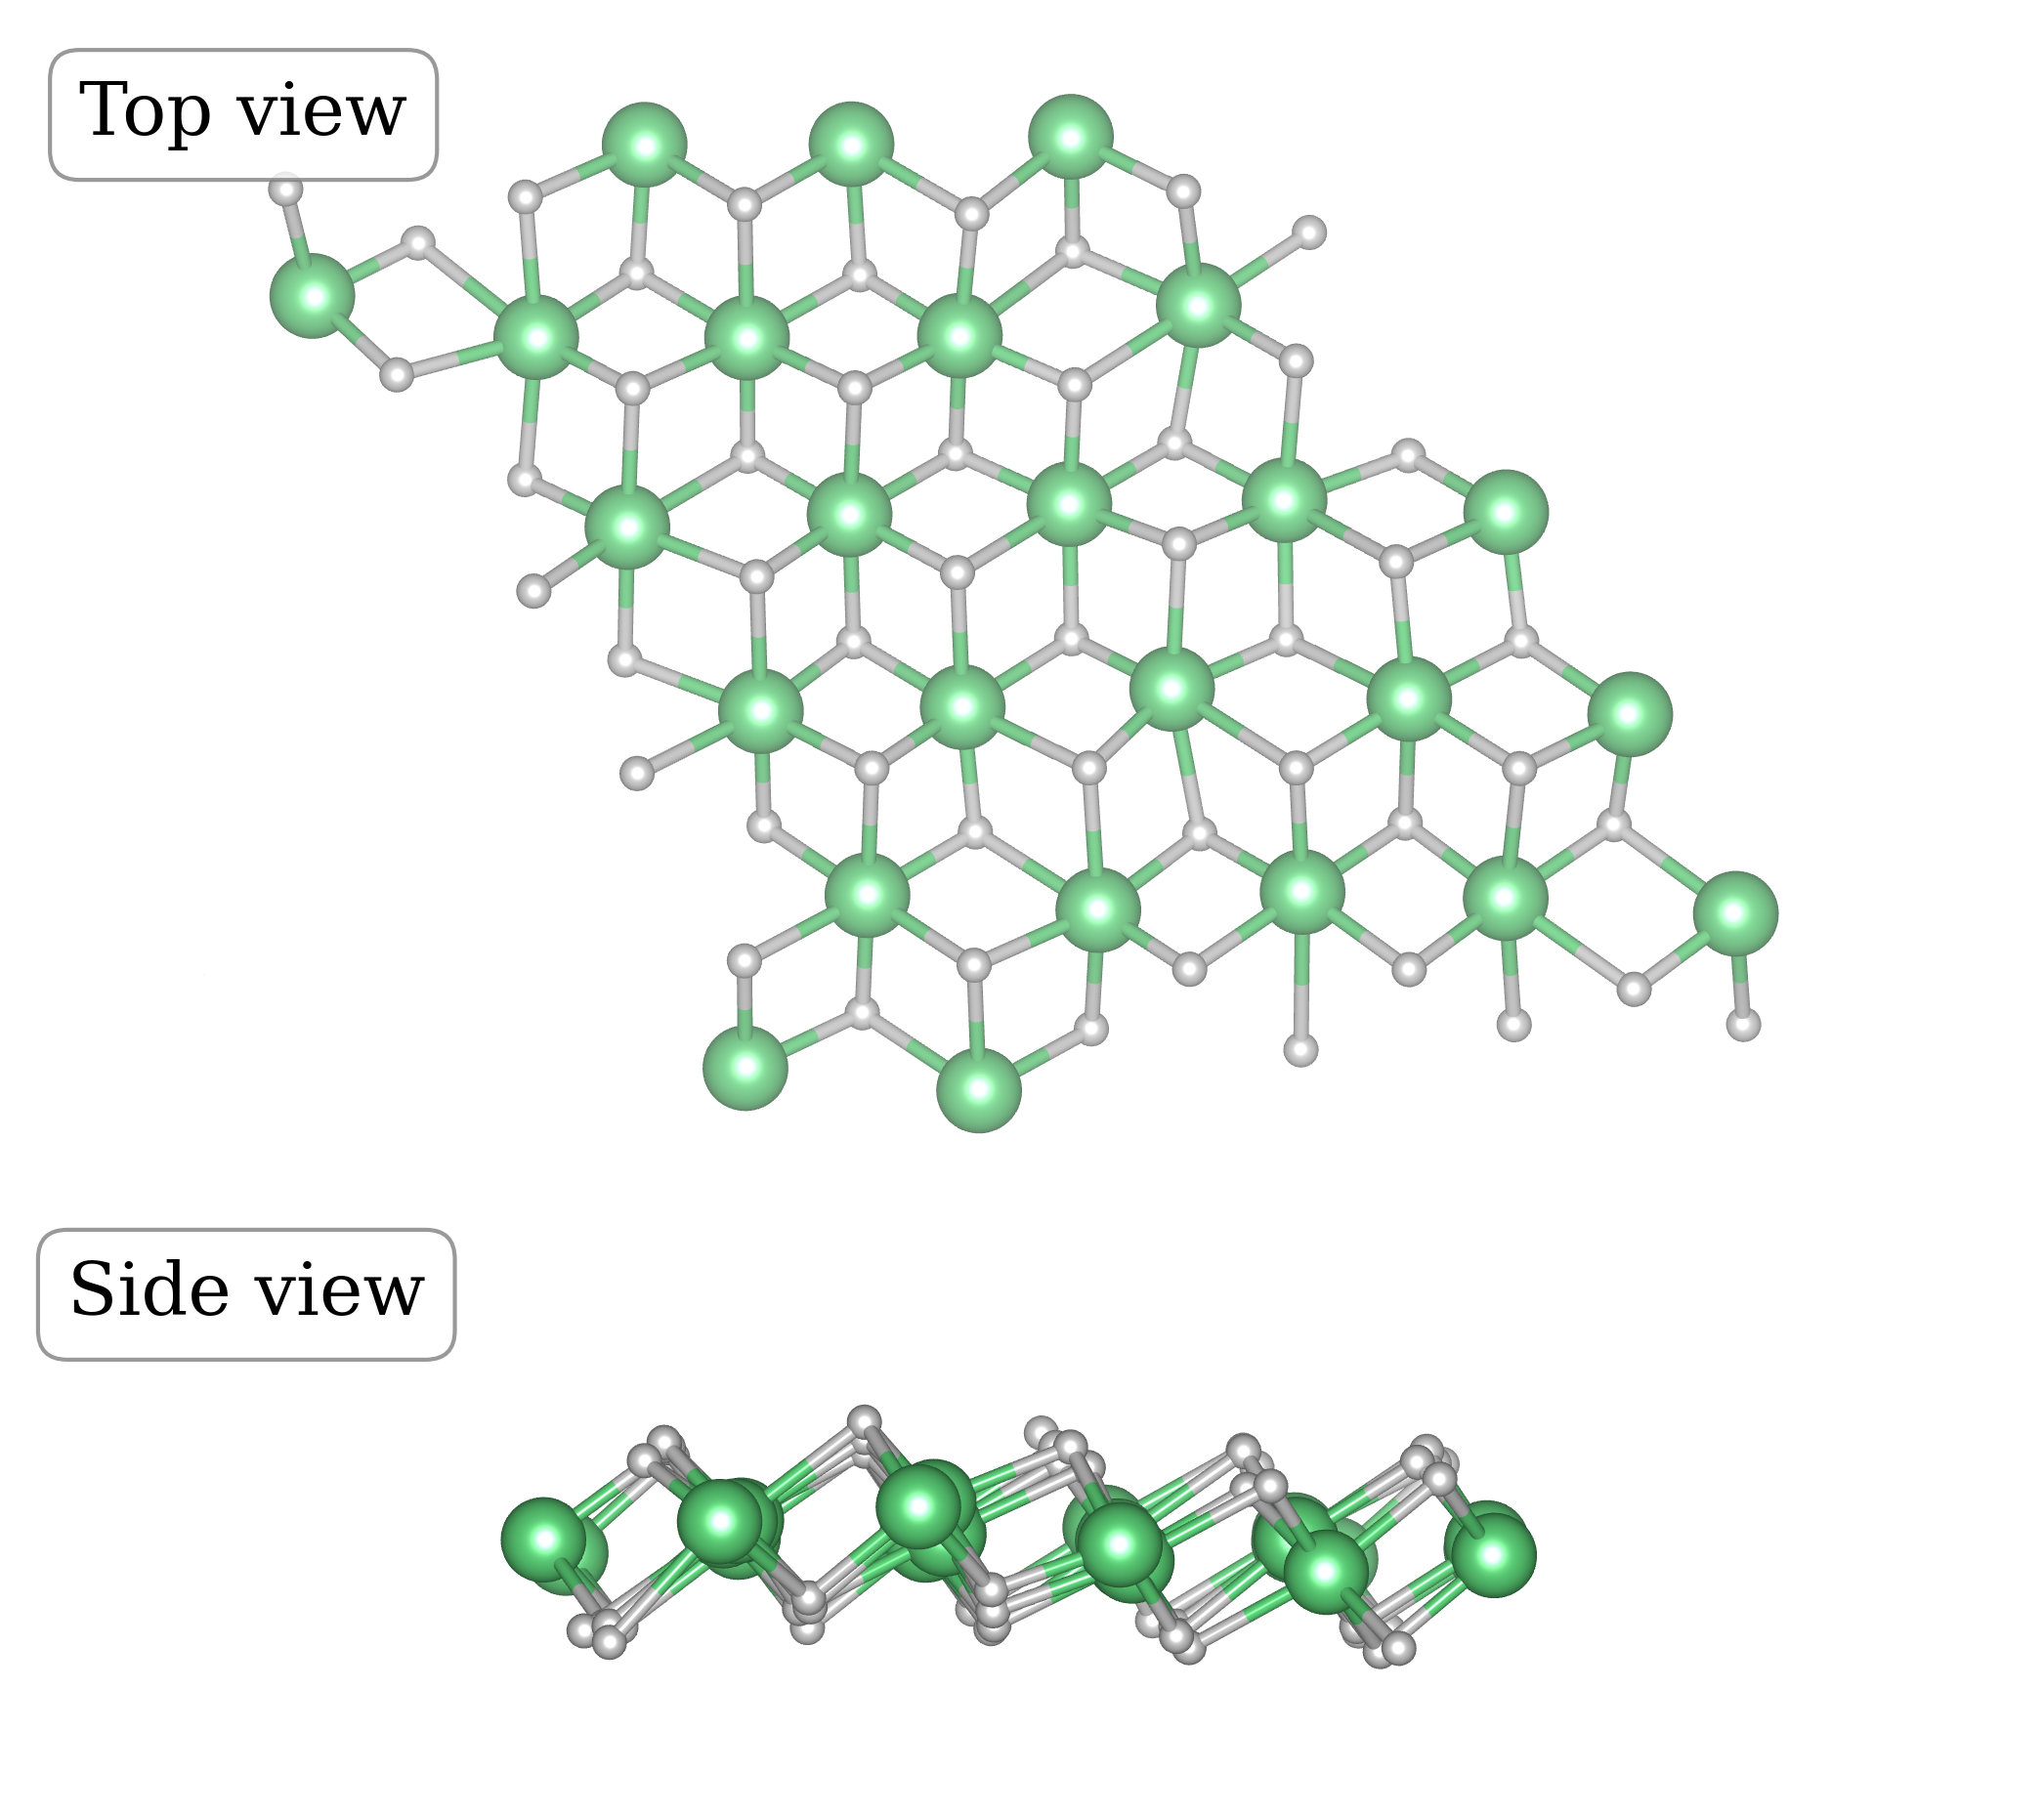

In [2]:
# a-beryllene_hh

merge_2_rasters_ver([
    ["a-beryllene_hh_top.png","Top view"],
    ["a-beryllene_hh_side.png","Side view"],
], border=False, divider=False)

plt.savefig("fig3.7a2.pdf")


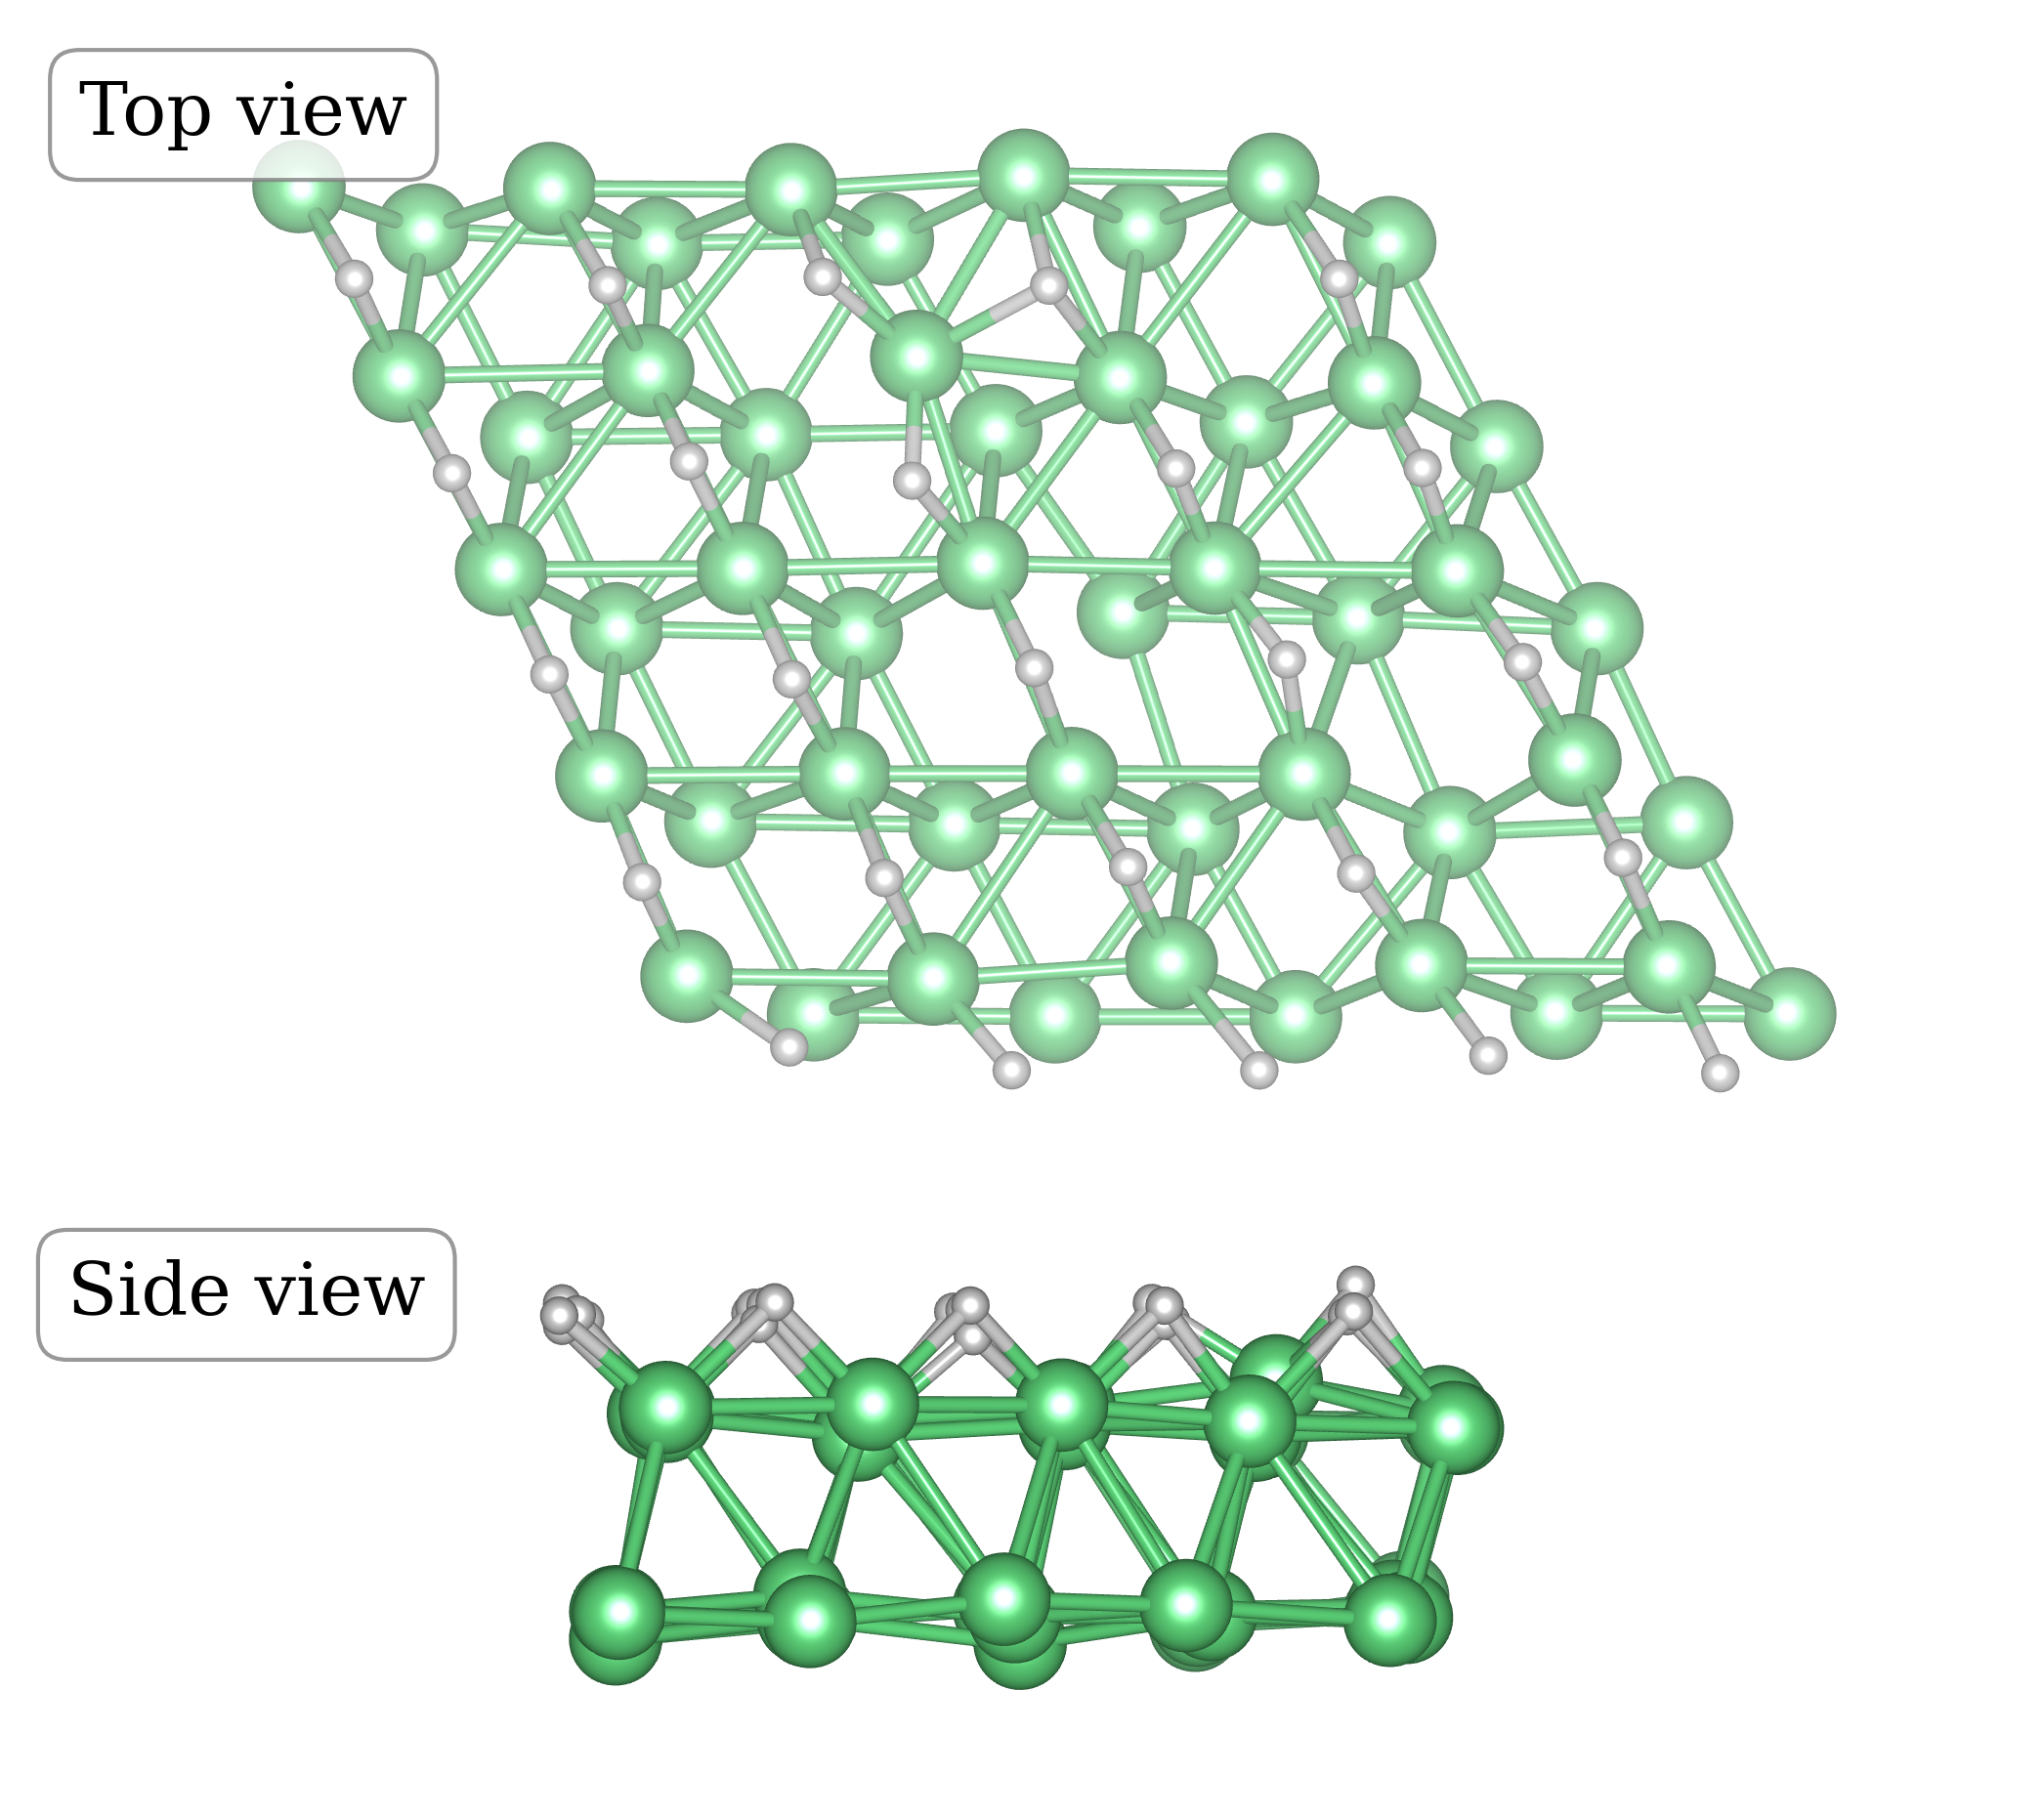

In [3]:
# b-beryllene_b

merge_2_rasters_ver([
    ["b-beryllene_b_top.png","Top view"],
    ["b-beryllene_b_side.png","Side view"],
], border=False, divider=False)

plt.savefig("fig3.7b2.pdf")


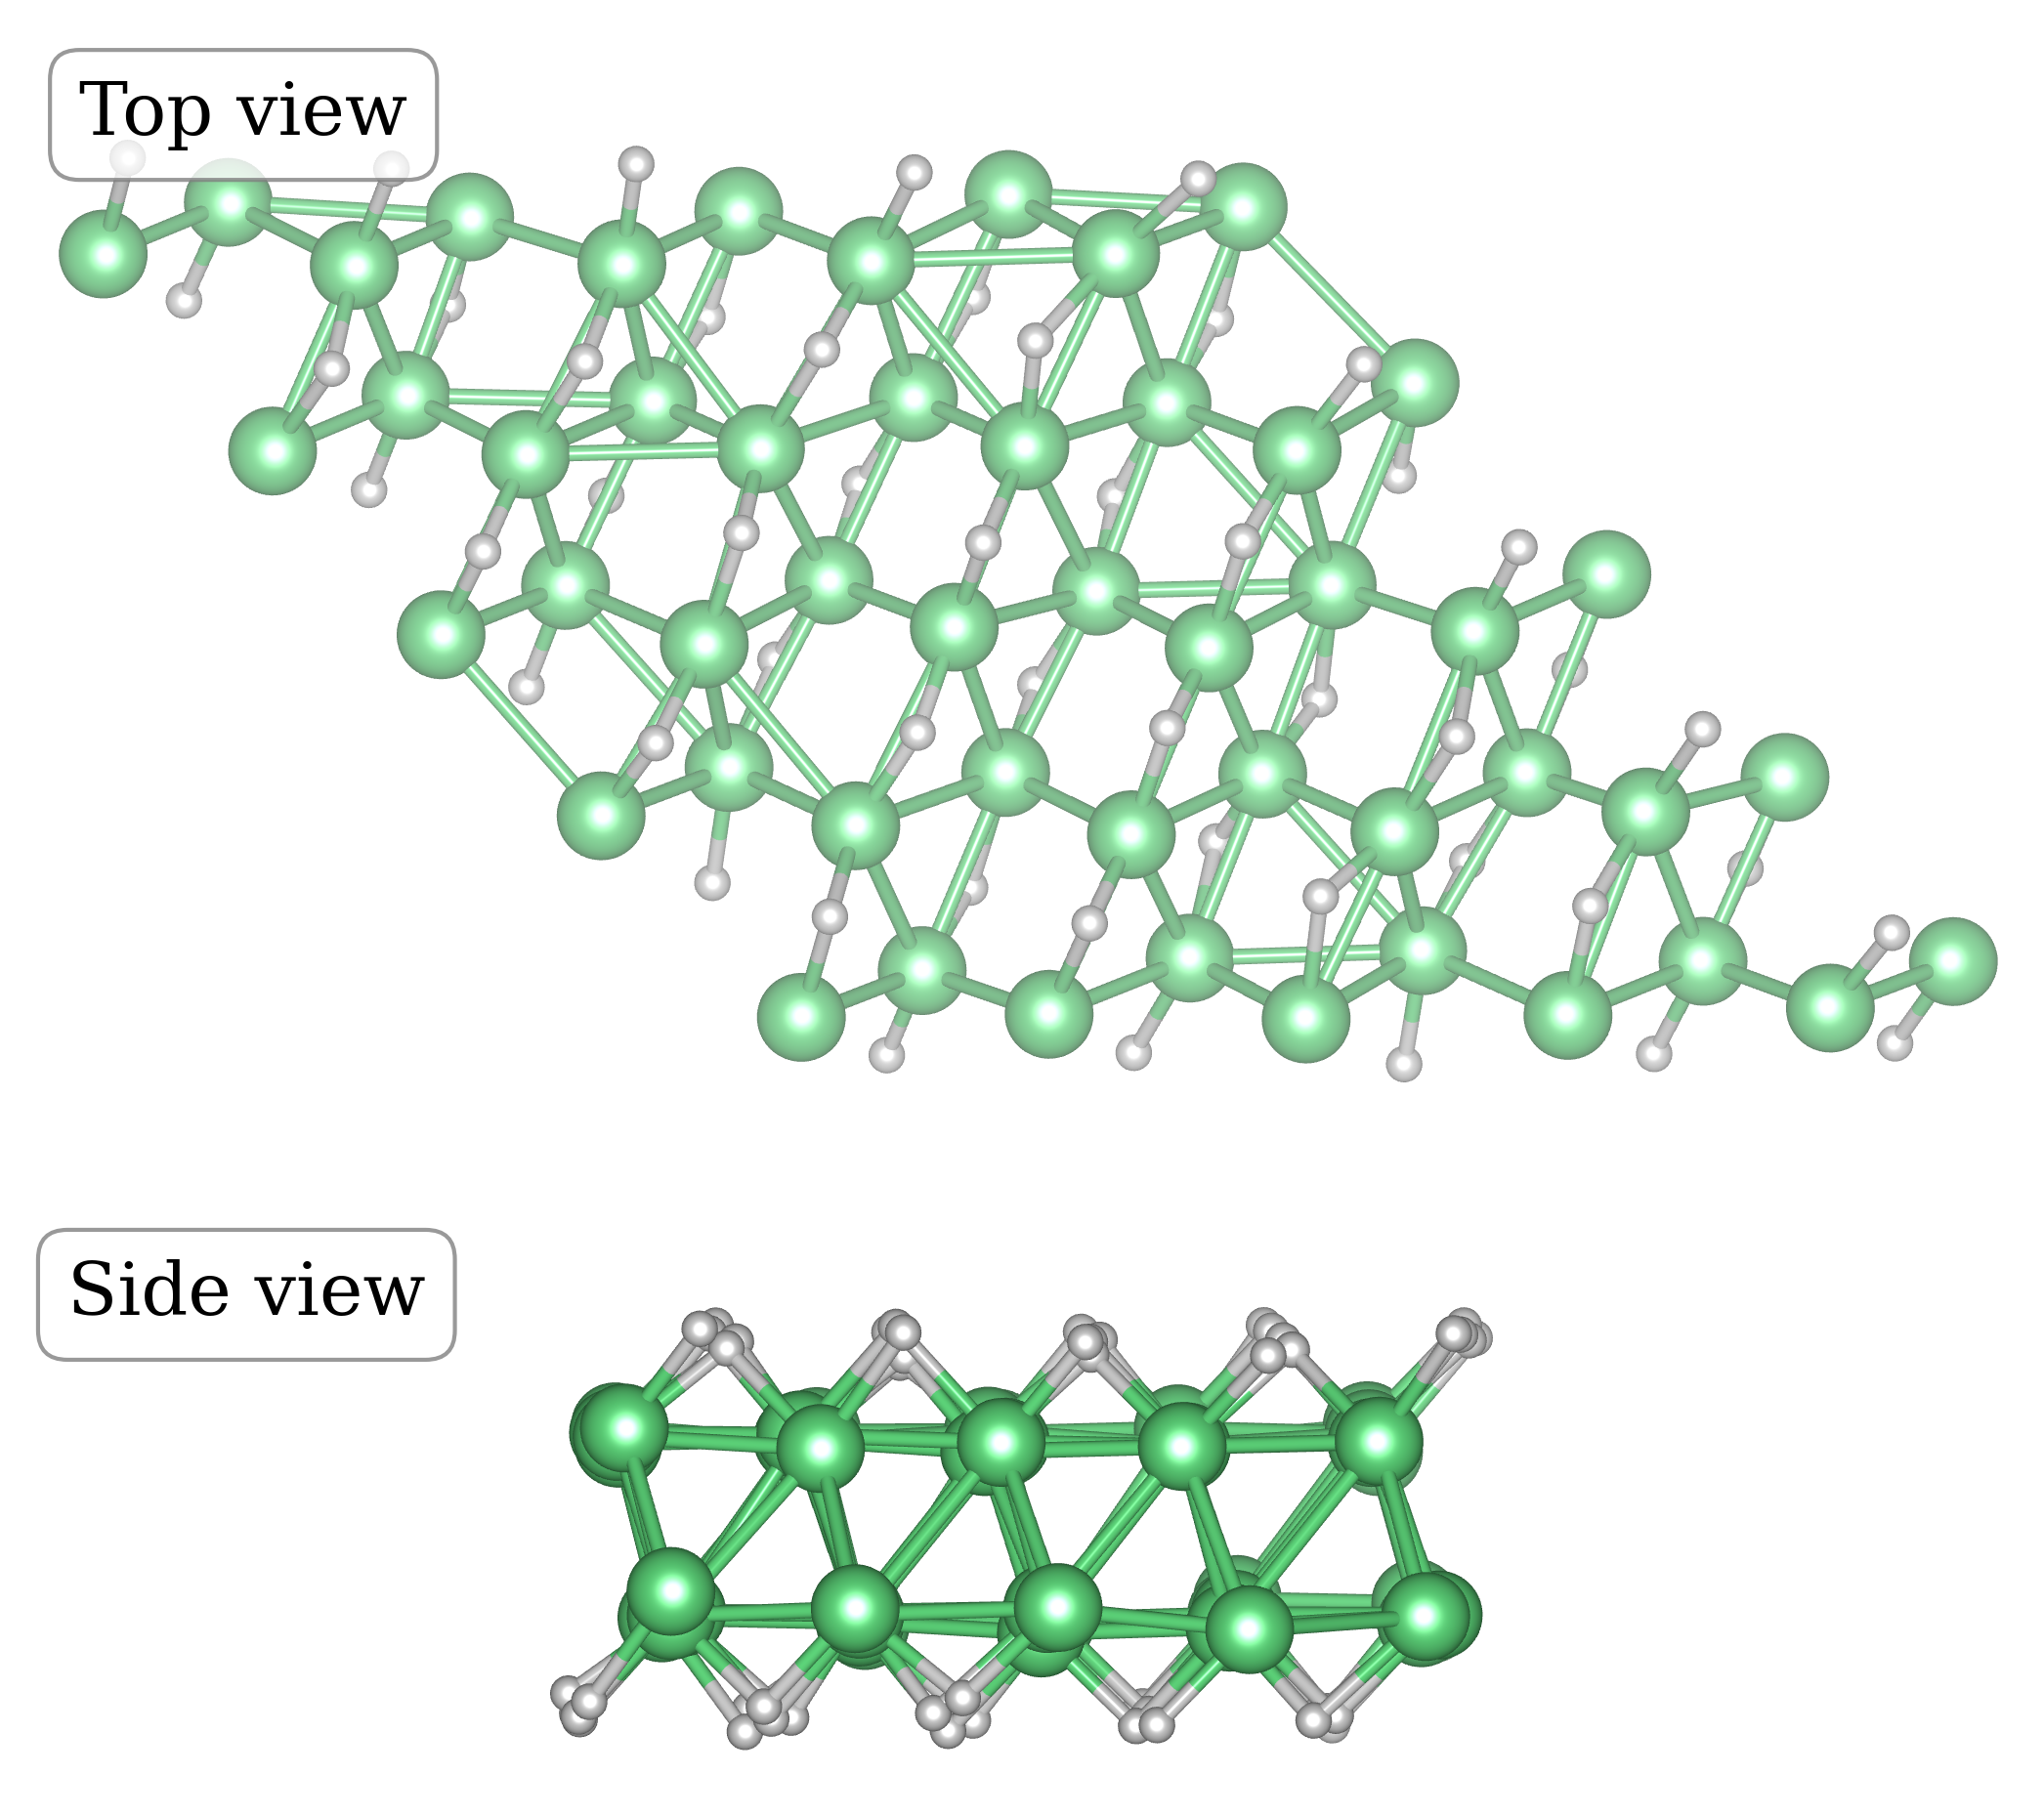

In [4]:
# b-beryllene_bb

merge_2_rasters_ver([
    ["b-beryllene_bb_top.png","Top view"],
    ["b-beryllene_bb_side.png","Side view"],
], border=False, divider=False)

plt.savefig("fig3.7c2.pdf")
